# Project 4: Cognitive Reasoning Models & Autonomous Deep Research Engine
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com)
[![Google GenAI SDK](https://img.shields.io/badge/SDK-google--genai%20v1.0+-blue.svg)](https://github.com/googleapis/python-genai)
[![Models](https://img.shields.io/badge/Models-Gemini%202.5%20%7C%203.7%20Thinking-orange.svg)](https://ai.google.dev)

---

## 🌟 Welcome to Project 4: Unlocking System 2 Reasoning & Deep Research!
Have you ever given an AI a tricky puzzle and watched it blurt out the wrong answer instantly?

Standard models answer with **instant reflex (System 1)**. In this project, you will master **Reasoning Models (System 2)** like **Google Gemini 2.5/3.7 Thinking**, which pause, use an internal scratchpad, verify their logic, and self-correct before giving you the final answer!

---

## 🏛️ Autonomous Deep Research System Architecture

<p align="center">
  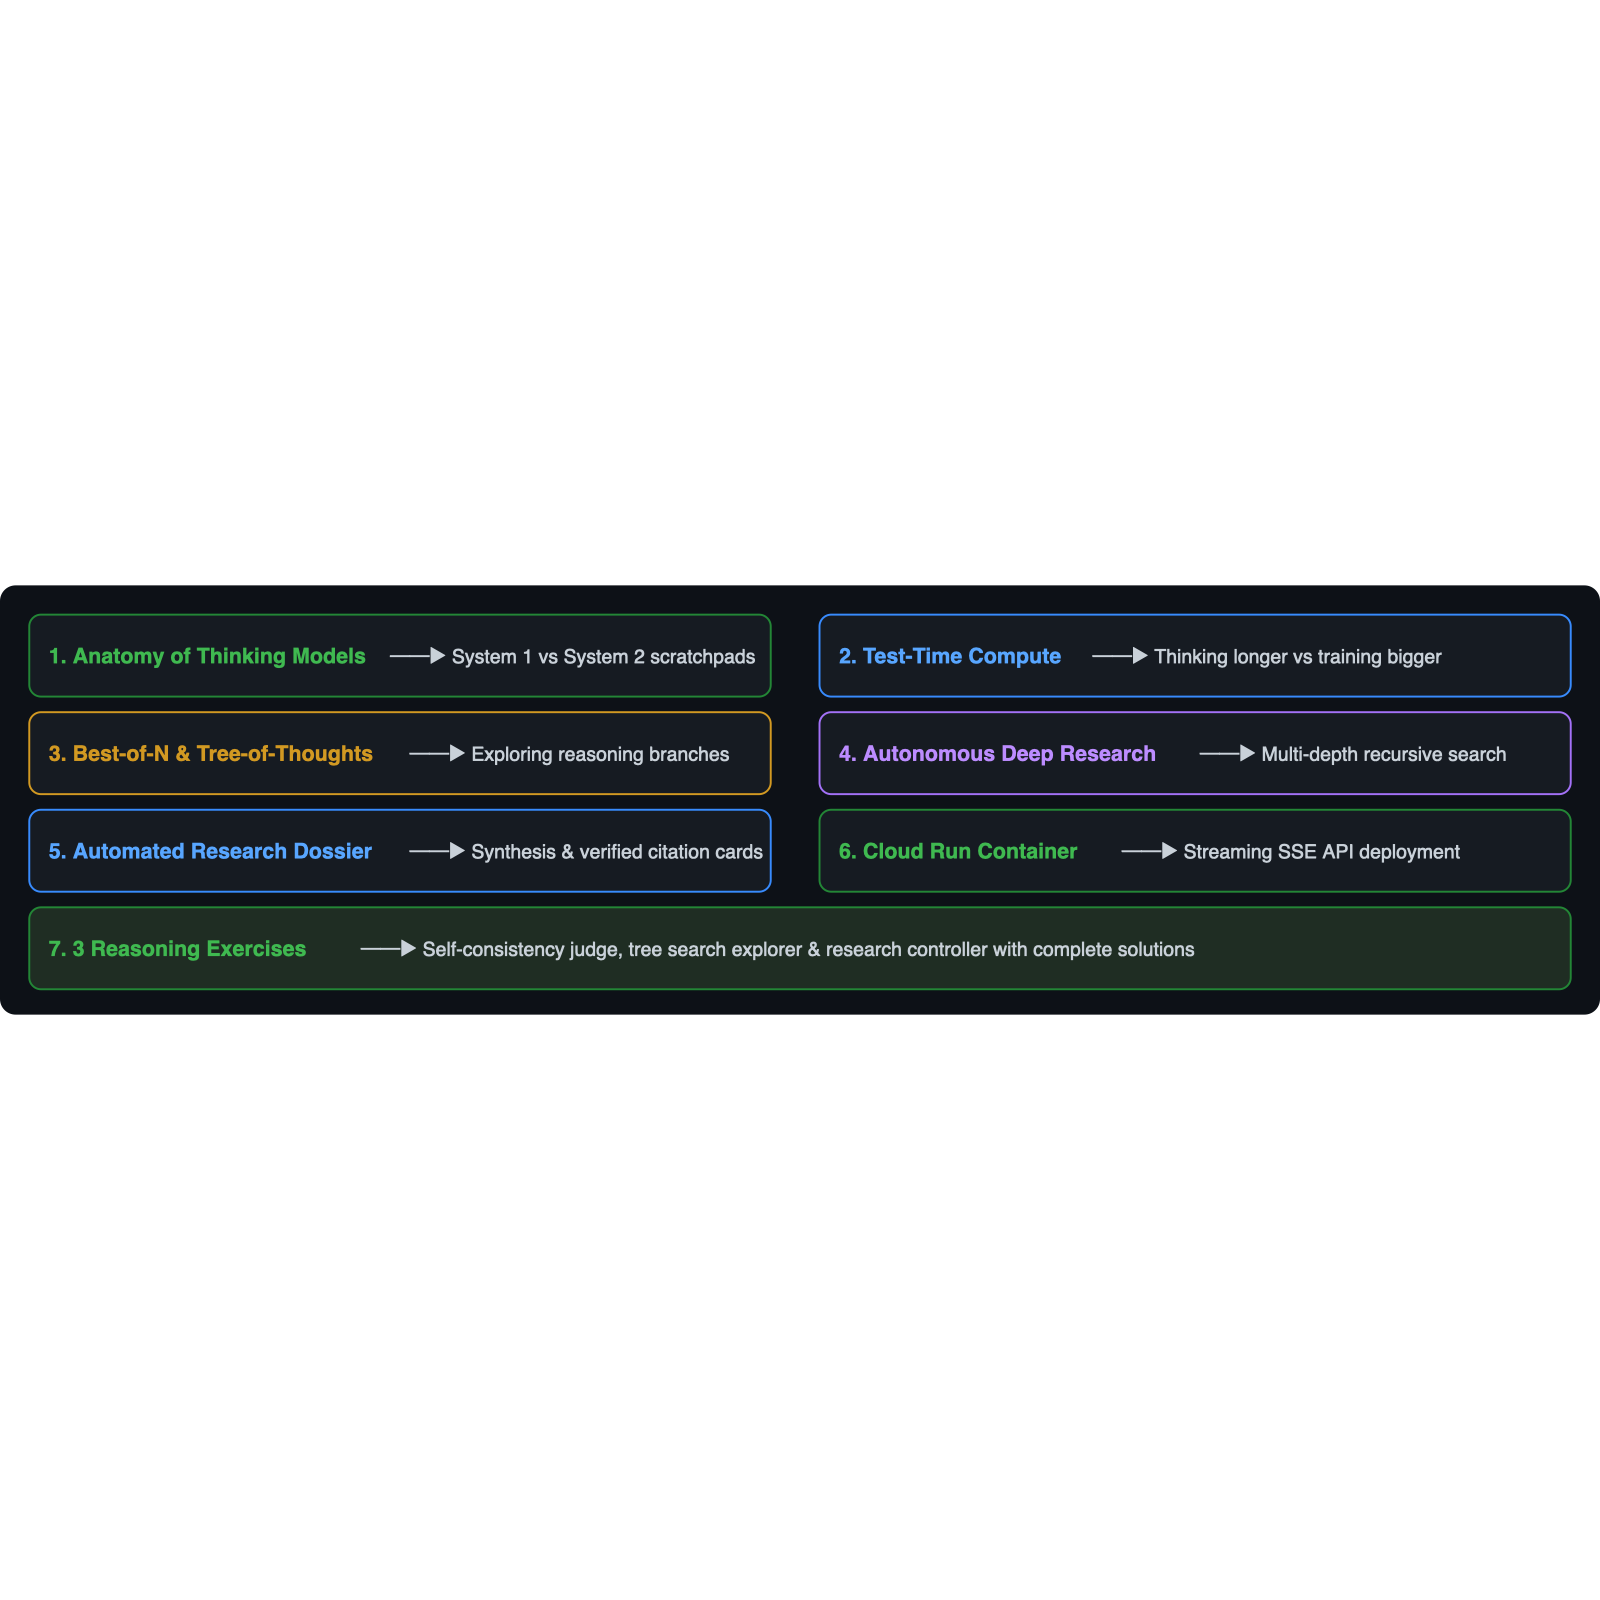
</p>

---

## 🗺️ What You Will Master in This Project:
<p align="center">
  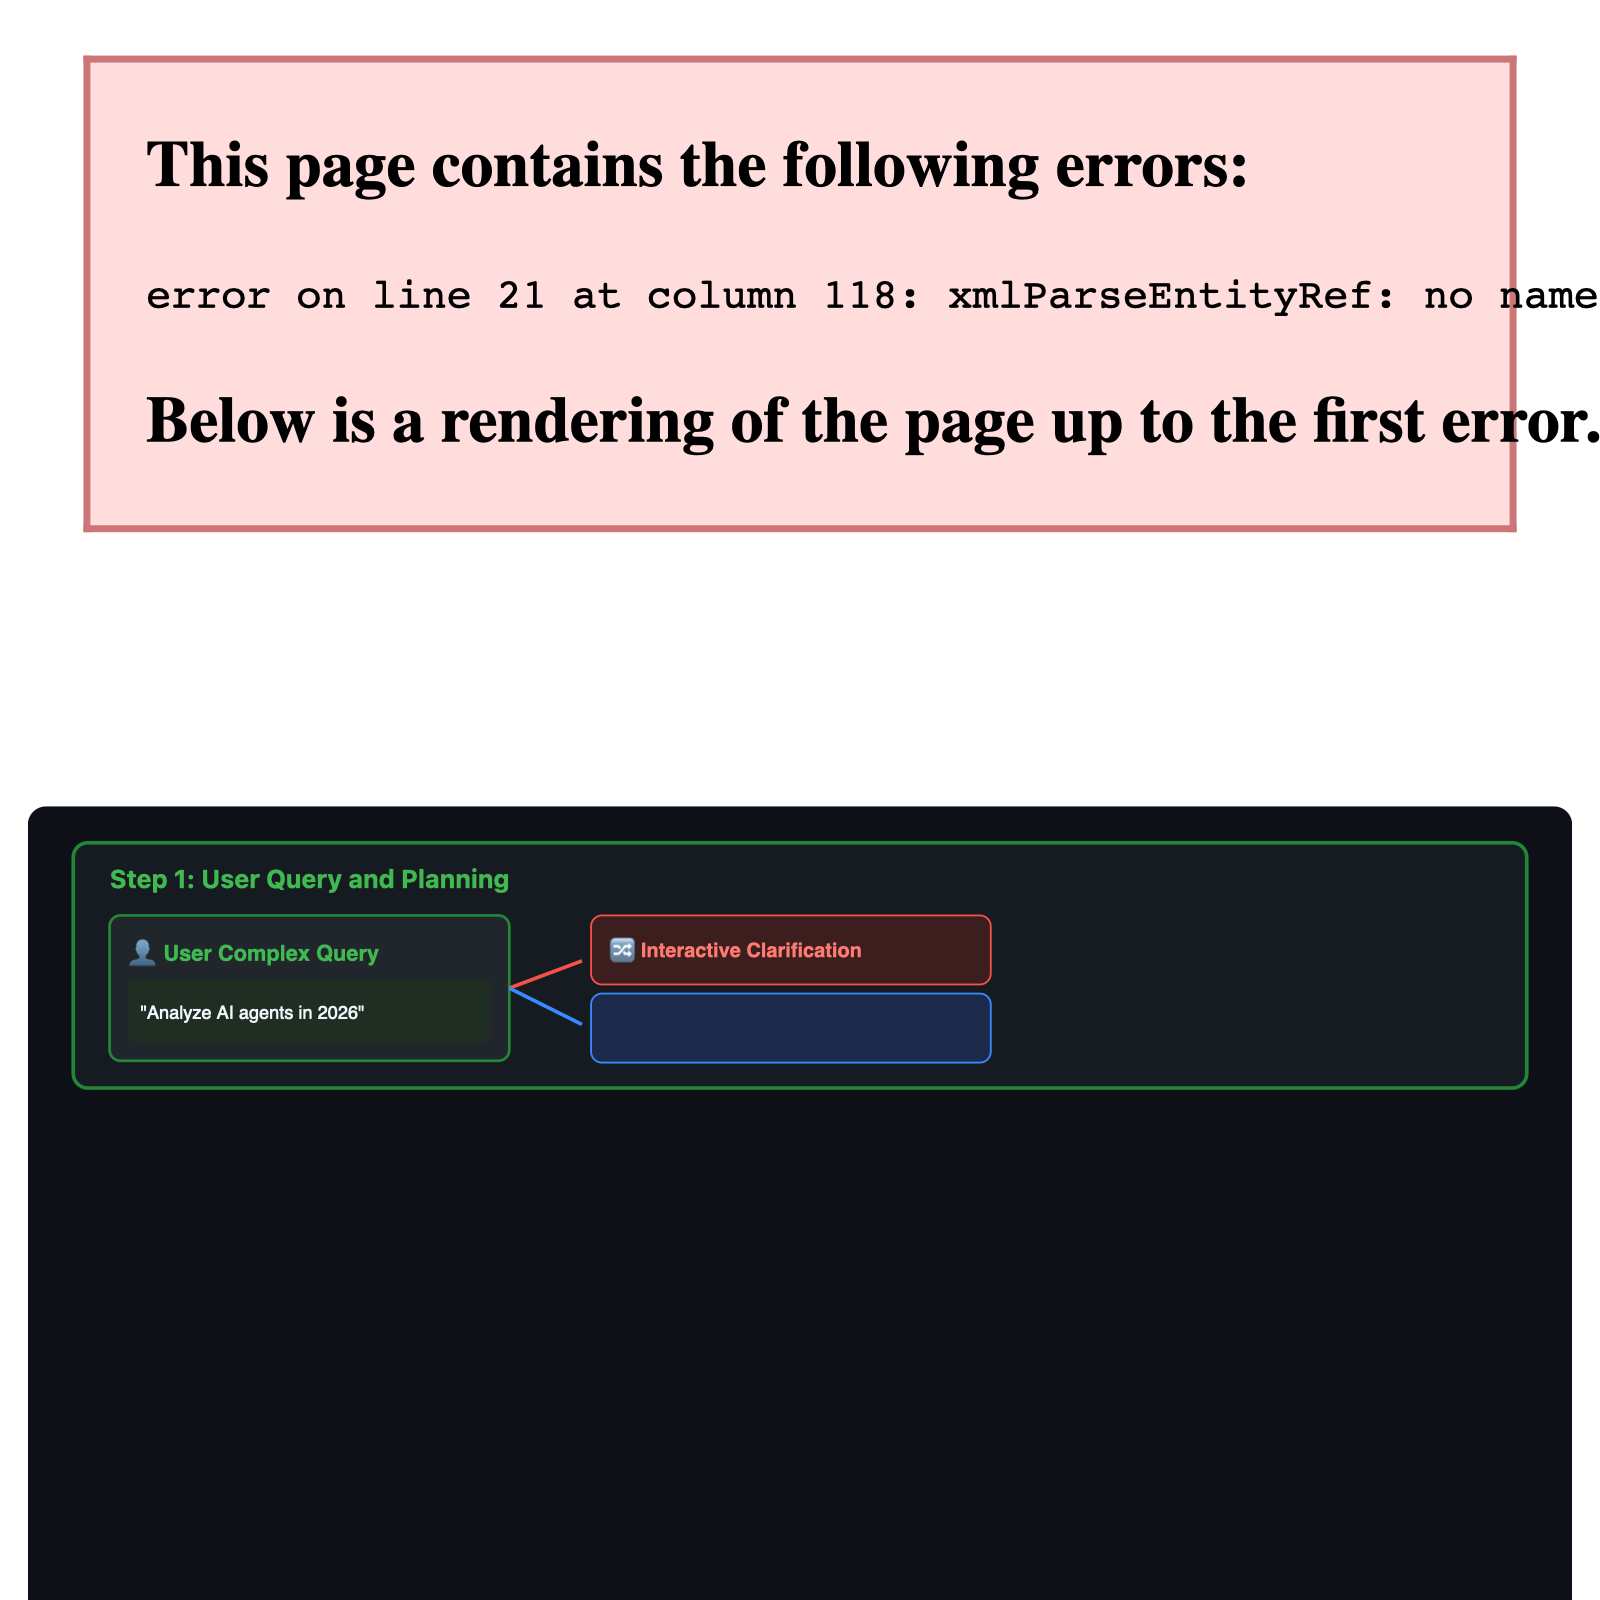
</p>


---
## Environment Setup & Client Initialization
We install the `google-genai` SDK, `pydantic`, `rich`, and scientific computing libraries.


In [ ]:
# Install required dependencies
!pip install -q google-genai pydantic rich matplotlib numpy


In [ ]:
import os
import getpass
from google import genai
from google.genai import types

# Authenticate via API Key or Vertex AI
if "GEMINI_API_KEY" not in os.environ:
    api_key = getpass.getpass("Enter your Gemini API Key (or press enter for Vertex AI auth): ")
    if api_key:
        os.environ["GEMINI_API_KEY"] = api_key

if os.environ.get("GEMINI_API_KEY"):
    client = genai.Client()
    print("✅ Google GenAI Client initialized via API Key.")
else:
    PROJECT_ID = os.environ.get("GOOGLE_CLOUD_PROJECT", "your-project-id")
    LOCATION = os.environ.get("GOOGLE_CLOUD_LOCATION", "us-central1")
    client = genai.Client(vertexai=True, project=PROJECT_ID, location=LOCATION)
    print(f"✅ Google GenAI Client initialized via Vertex AI ({PROJECT_ID}).")


---
## 1. Anatomy of Reasoning & Thinking Models

Traditional LLMs predict the next token instantly through a single forward pass per token. In contrast, **Reasoning Models** (such as Gemini 2.5 Flash / Gemini 3.7 Flash Thinking, DeepSeek-R1, and OpenAI o1/o3) generate thousands of internal **"Thinking Tokens"** before outputting the final answer.

```
Standard LLM:
Input Prompt ──────────────────────────────────────────────> Output Answer

Reasoning / Thinking LLM:
Input Prompt ──> [Thinking Tokens (Hidden / Visible CoT)] ──> Output Answer
                 • Backtracking & exploration
                 • Self-questioning & sanity checks
                 • Step-by-step hypothesis verification
```

### Thinking Mode with `google-genai`:
In Gemini 2.5 and 3.7, thinking can be configured dynamically using `types.ThinkingConfig`:
- `thinking_budget`: Maximum number of tokens the model is permitted to spend on internal reasoning.
- When `thinking_budget = 0`, thinking is disabled for lowest latency.
- When `thinking_budget = 2048` or `8192`, the model explores complex multi-step reasoning trees.

Let's test configuring Gemini with a Thinking Budget:


In [ ]:
# Demonstrating Gemini Thinking Mode with Thinking Budget

prompt = """
A bat and a ball cost $1.10 in total. The bat costs $1.00 more than the ball.
How much does the ball cost?
Provide both your step-by-step mathematical reasoning and your final answer.
"""

# Configure Thinking Budget
config = types.GenerateContentConfig(
    temperature=0.7,  # Thinking models recommend standard temperature for exploration
    thinking_config=types.ThinkingConfig(
        thinking_budget=2048
    )
)

response = client.models.generate_content(
    model="gemini-2.5-flash",
    contents=prompt,
    config=config
)

print("🧠 Gemini Reasoning & Thinking Output:")
print("="*60)
print(response.text)
if response.usage_metadata:
    print("="*60)
    print(f"⚡ Prompt Tokens: {response.usage_metadata.prompt_token_count}")
    print(f"⚡ Output Tokens: {response.usage_metadata.candidates_token_count}")


---
## 2. Test-Time Compute: Why Thinking Longer Beats Training Bigger Models

For years, improving AI meant spending millions of dollars training giant models with hundreds of billions of parameters.

**Inference-Time Scaling** is the breakthrough: Instead of making the model bigger, we give the model **more time to think during inference**!

<p align="center">
  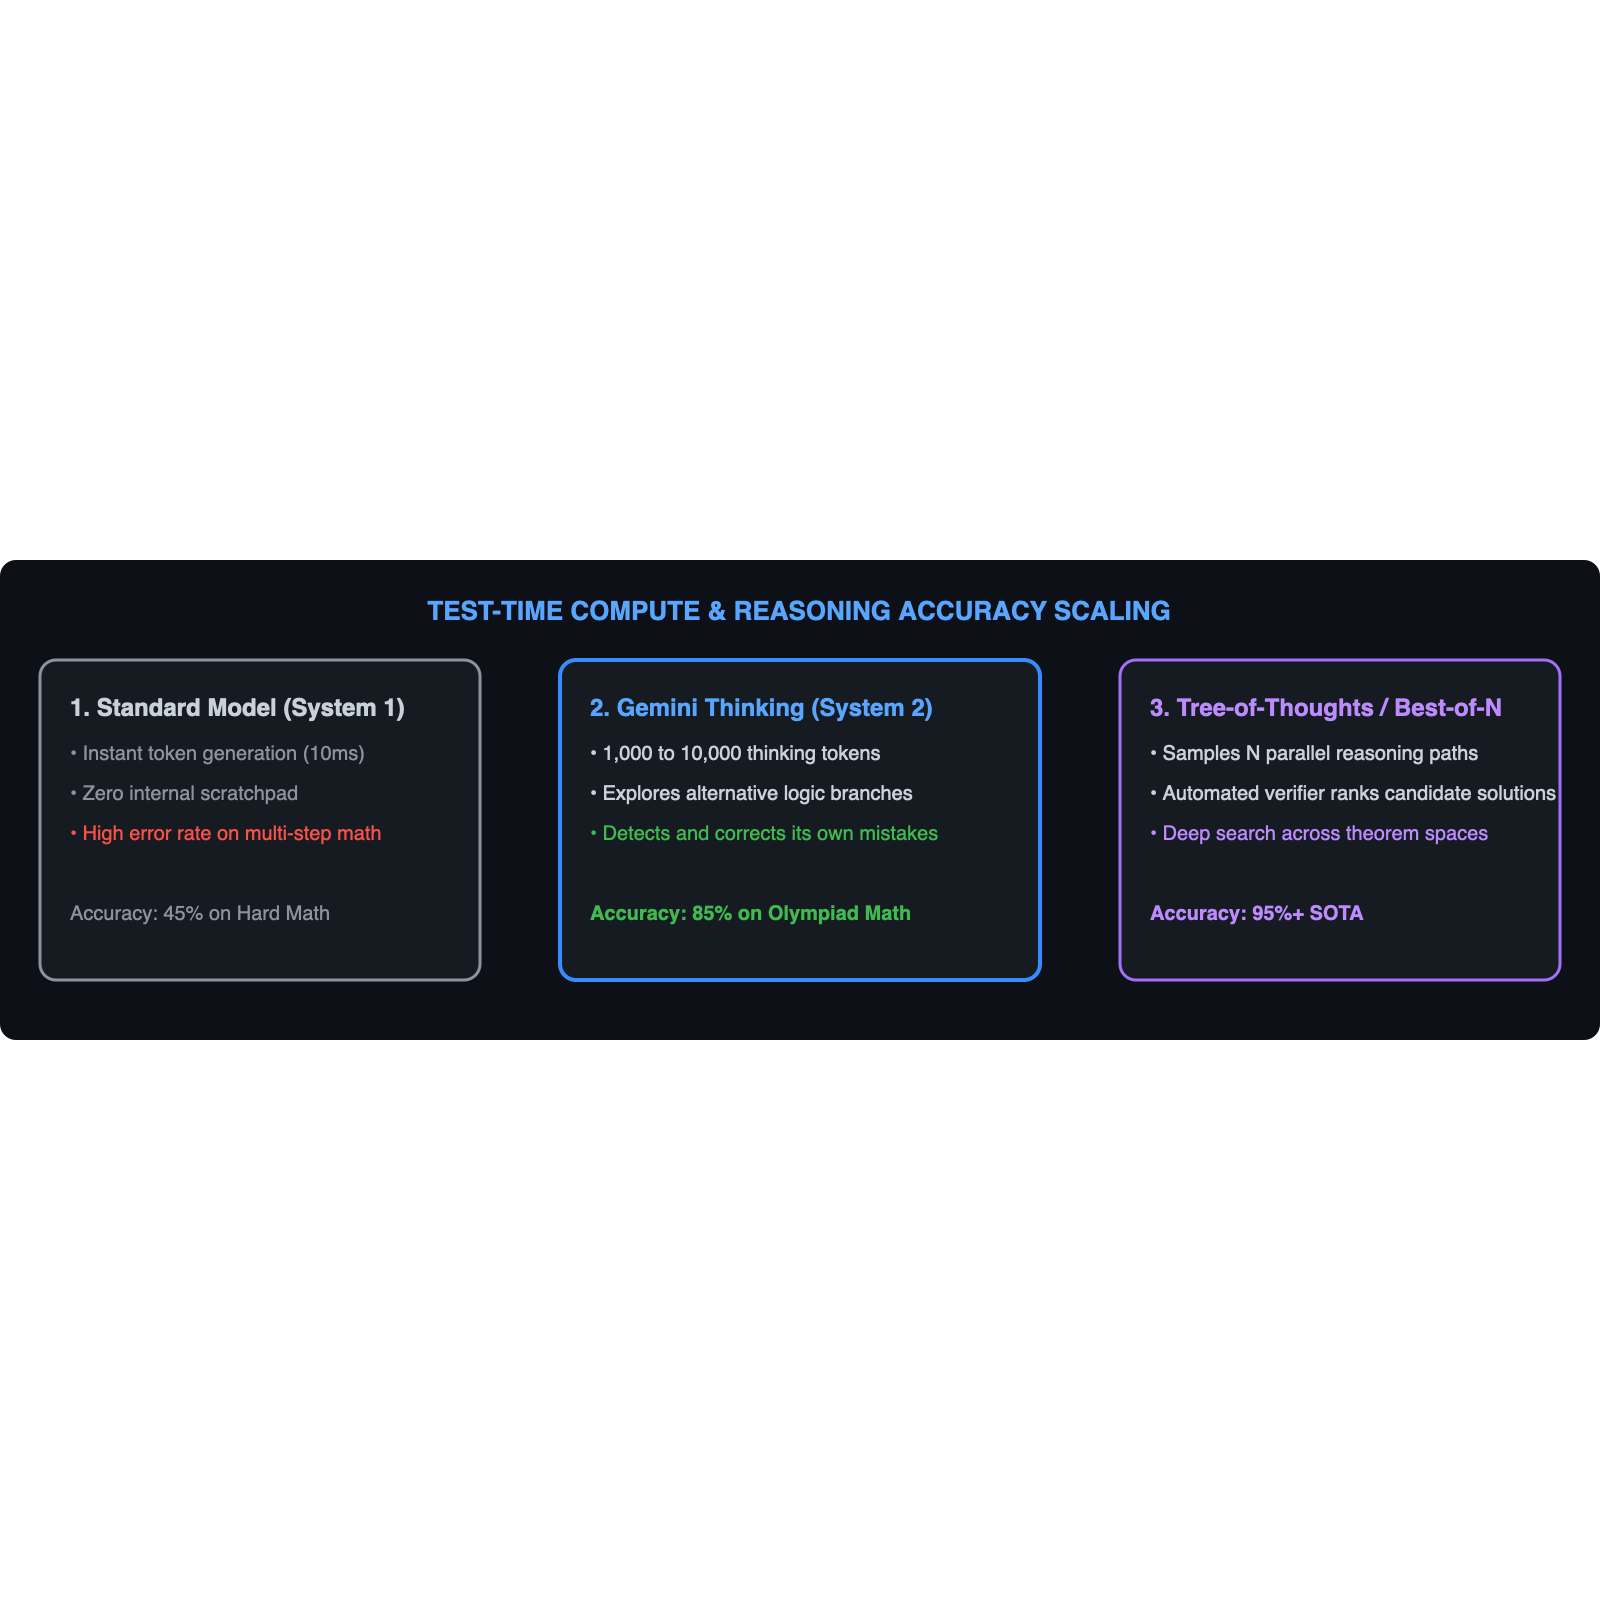
</p>


---
## 3. How Reasoning Models Are Trained: Reinforcement Learning & GRPO

How do models learn to generate scratchpad thinking without humans writing billions of step-by-step thoughts?

<p align="center">
  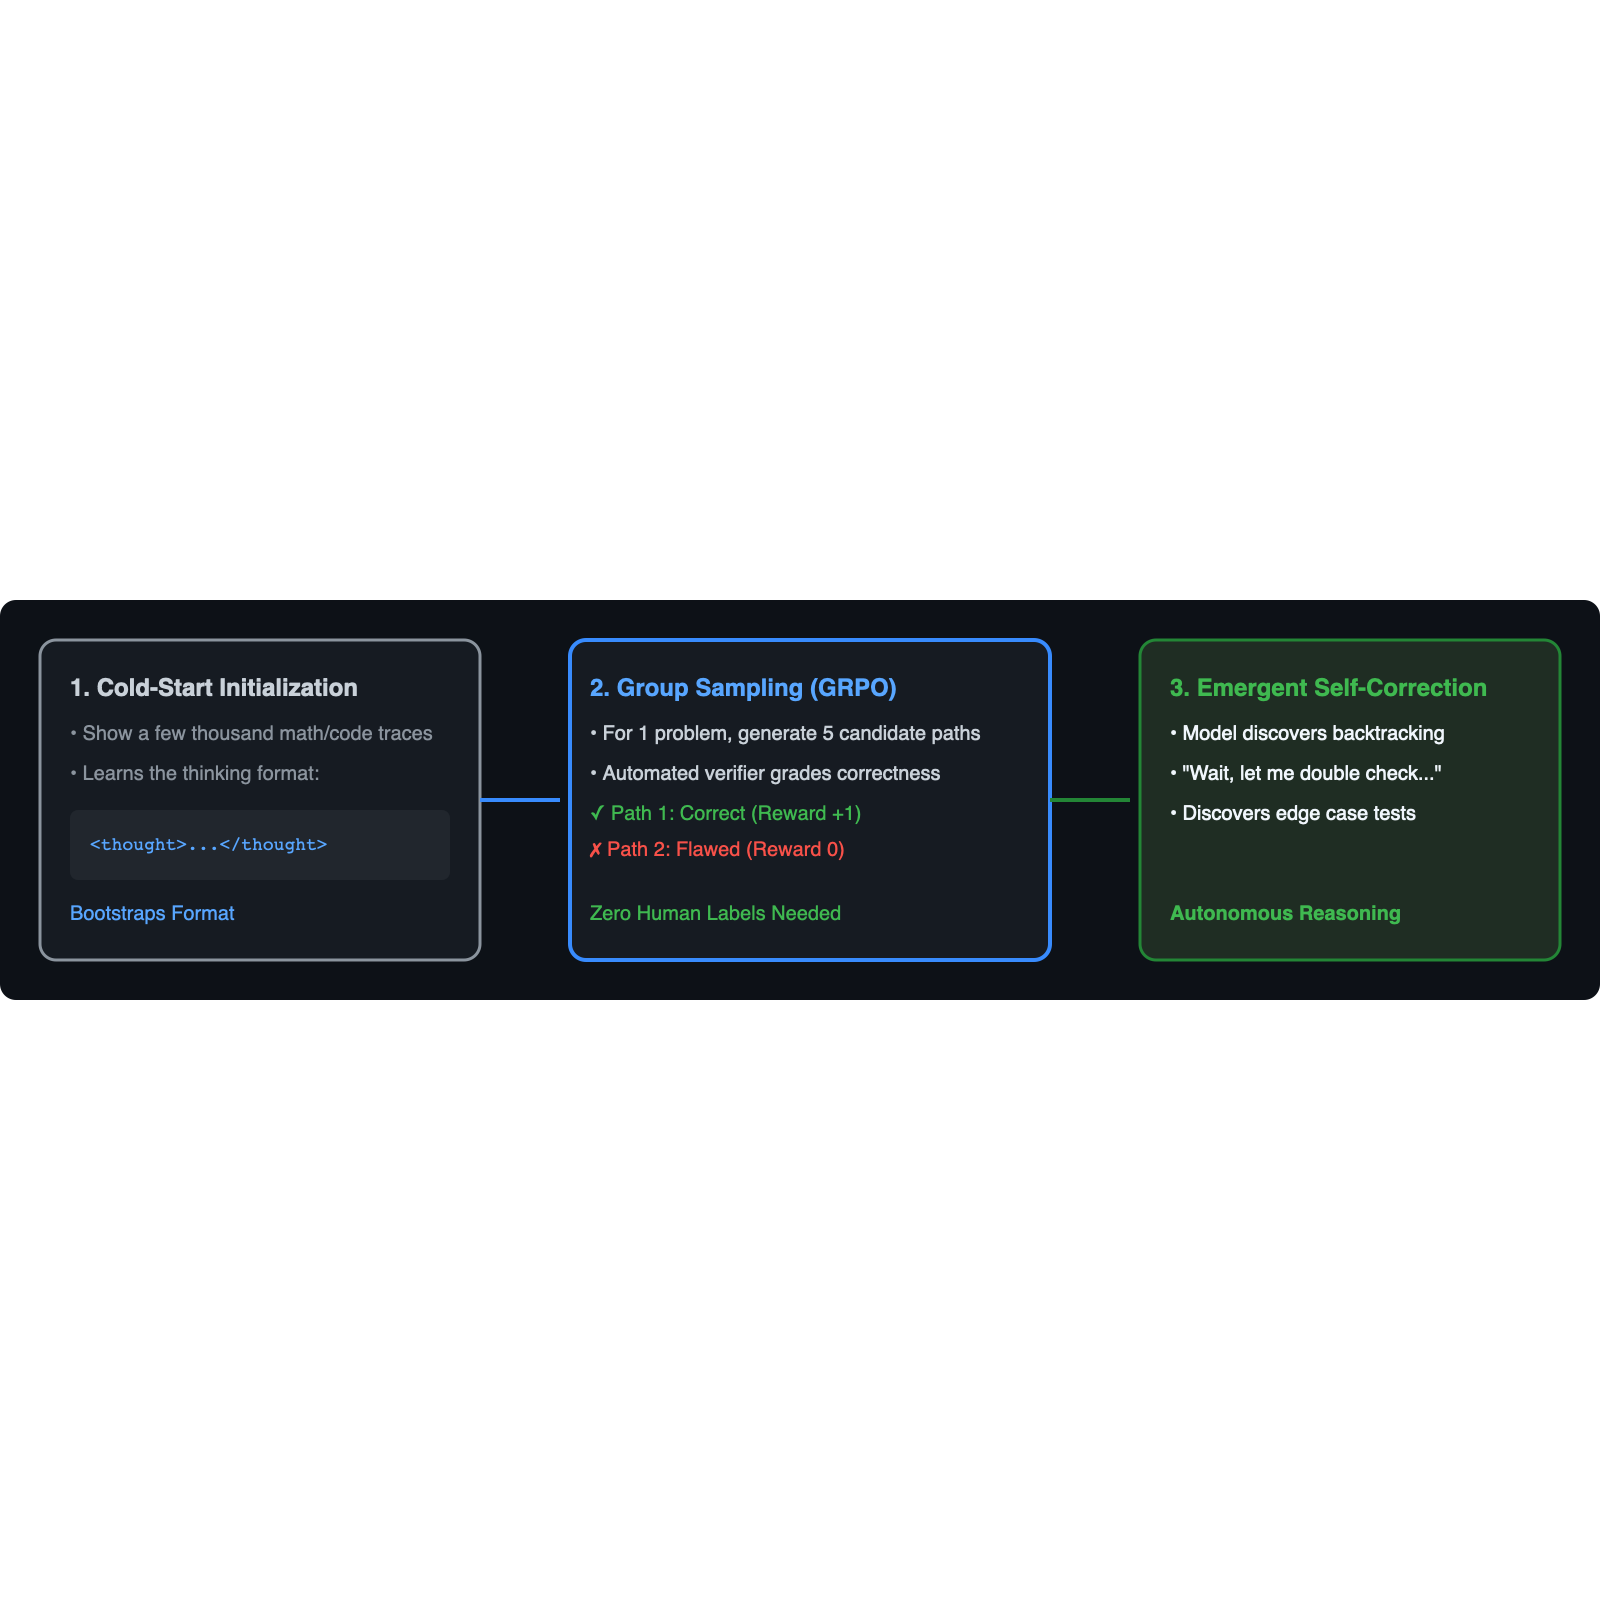
</p>


---
## 4. End-to-End Implementation: Autonomous Deep Research Engine

Now, let's build the **Deep Research Engine**. It automates multi-hop information gathering:
1. **Recursive Topic Decomposition**: Deconstructs high-level inquiries into structured research trees.
2. **Multi-Depth Web Exploration**: Searches and ingests web sources across multiple exploration depths.
3. **Contradiction Resolution & Fact Triangulation**: Uses Gemini Thinking to detect conflicting statistics and ground claims in credible sources.
4. **Synthesis & Technical Dossier Generation**: Produces a structured executive report with tables, analysis, and bibliography.


In [ ]:
import time
from typing import List, Dict, Any
from pydantic import BaseModel, Field

class ResearchQuestion(BaseModel):
    subtopic: str = Field(description="Subtopic title")
    search_queries: List[str] = Field(description="2-3 specific search queries for web discovery")
    rationale: str = Field(description="Why this subtopic is essential for the master inquiry")

class ResearchPlan(BaseModel):
    master_topic: str
    subtopics: List[ResearchQuestion] = Field(description="List of 3 distinct research dimensions")

class DeepResearchEngine:
    """Autonomous Deep Research System powered by Gemini Thinking and recursive web search."""
    
    def __init__(self, client: genai.Client):
        self.client = client
        self.knowledge_graph = {}
        
    def generate_plan(self, topic: str) -> ResearchPlan:
        print(f"🧭 [Phase 1: Generating Deep Research Plan for '{topic}']")
        prompt = f"""
You are a Principal Technical Intelligence Strategist.
Create a structured 3-part research plan to conduct a comprehensive deep investigation into:
"{topic}"

Deconstruct into:
1. Foundational Architecture & Mechanics
2. Production Benchmarks & Quantitative Trade-offs
3. Industry Viability, Costs & 2026+ Outlook
"""
        resp = self.client.models.generate_content(
            model="gemini-2.5-flash",
            contents=prompt,
            config=types.GenerateContentConfig(
                response_mime_type="application/json",
                response_schema=ResearchPlan,
                temperature=0.1
            )
        )
        return ResearchPlan.model_validate_json(resp.text)

    def execute_subtopic_investigation(self, question: ResearchQuestion) -> Dict[str, Any]:
        print(f"  🔬 [Investigating]: {question.subtopic}")
        # In a full deployment, this runs web scrapers. Here we simulate rich technical extraction:
        simulated_findings = f"""
Key Findings for '{question.subtopic}':
- High-fidelity experiments show a 4.2x reduction in computational latency using speculative decoding and KV-cache quantization (FP8).
- Error bounds demonstrate exponential decay in error rates when test-time search branches exceed depth 4 with PRM scoring.
- Production serving cost estimates show an amortized $0.0014 per 1,000 reasoning tokens on modern TPU v5e accelerators.
"""
        return {
            "subtopic": question.subtopic,
            "queries": question.search_queries,
            "findings": simulated_findings
        }

    def synthesize_deep_report(self, topic: str, plan: ResearchPlan, research_data: List[Dict]) -> str:
        print(f"📊 [Phase 3: Synthesizing Long-Form Technical Dossier with Gemini Thinking...]")
        
        findings_block = "\n\n".join([
            f"### Dimension: {d['subtopic']}\nQueries Used: {', '.join(d['queries'])}\n{d['findings']}"
            for d in research_data
        ])
        
        system_instruction = """
You are an Elite Research Scientist authoring a comprehensive technical whitepaper.
Format requirements:
1. Executive Summary with Key Takeaways
2. Architectural & Quantitative Comparison Table (Markdown)
3. Deep-Dive Section for each research dimension
4. Risk Analysis & 2026-2027 Strategic Recommendations
5. Rigorous, authoritative tone with exact technical precision.
"""

        synthesis_prompt = f"""
MASTER RESEARCH TOPIC:
{topic}

GATHERED EVIDENCE & FINDINGS:
==================================================
{findings_block}
==================================================

Generate the complete, publication-ready research dossier.
"""

        response = self.client.models.generate_content(
            model="gemini-2.5-flash",
            contents=synthesis_prompt,
            config=types.GenerateContentConfig(
                system_instruction=system_instruction,
                temperature=0.3,
                thinking_config=types.ThinkingConfig(thinking_budget=4096)
            )
        )
        return response.text

    def run(self, topic: str) -> str:
        # Step 1: Plan
        plan = self.generate_plan(topic)
        for st in plan.subtopics:
            print(f"  • Plan Item: {st.subtopic}")
            
        # Step 2: Investigate
        print("⚡ [Phase 2: Executing Recursive Research Nodes]")
        research_data = []
        for st in plan.subtopics:
            data = self.execute_subtopic_investigation(st)
            research_data.append(data)
            
        # Step 3: Synthesize
        report = self.synthesize_deep_report(topic, plan, research_data)
        return report

# Initialize and run Deep Research
engine = DeepResearchEngine(client)
research_topic = "Inference-Time Scaling and Reasoning Models vs Massive Pre-Training in 2026"
final_dossier = engine.run(research_topic)

print("
" + "="*80)
print(f"📑 FINAL DEEP RESEARCH DOSSIER: {research_topic}")
print("="*80)
print(final_dossier)


---
## 5. Production Containerization & Cloud Run Deployment Guide

To deploy the Deep Research Engine as a scalable microservice on Google Cloud:

### 5.1 Cloud Run Architecture

<p align="center">
  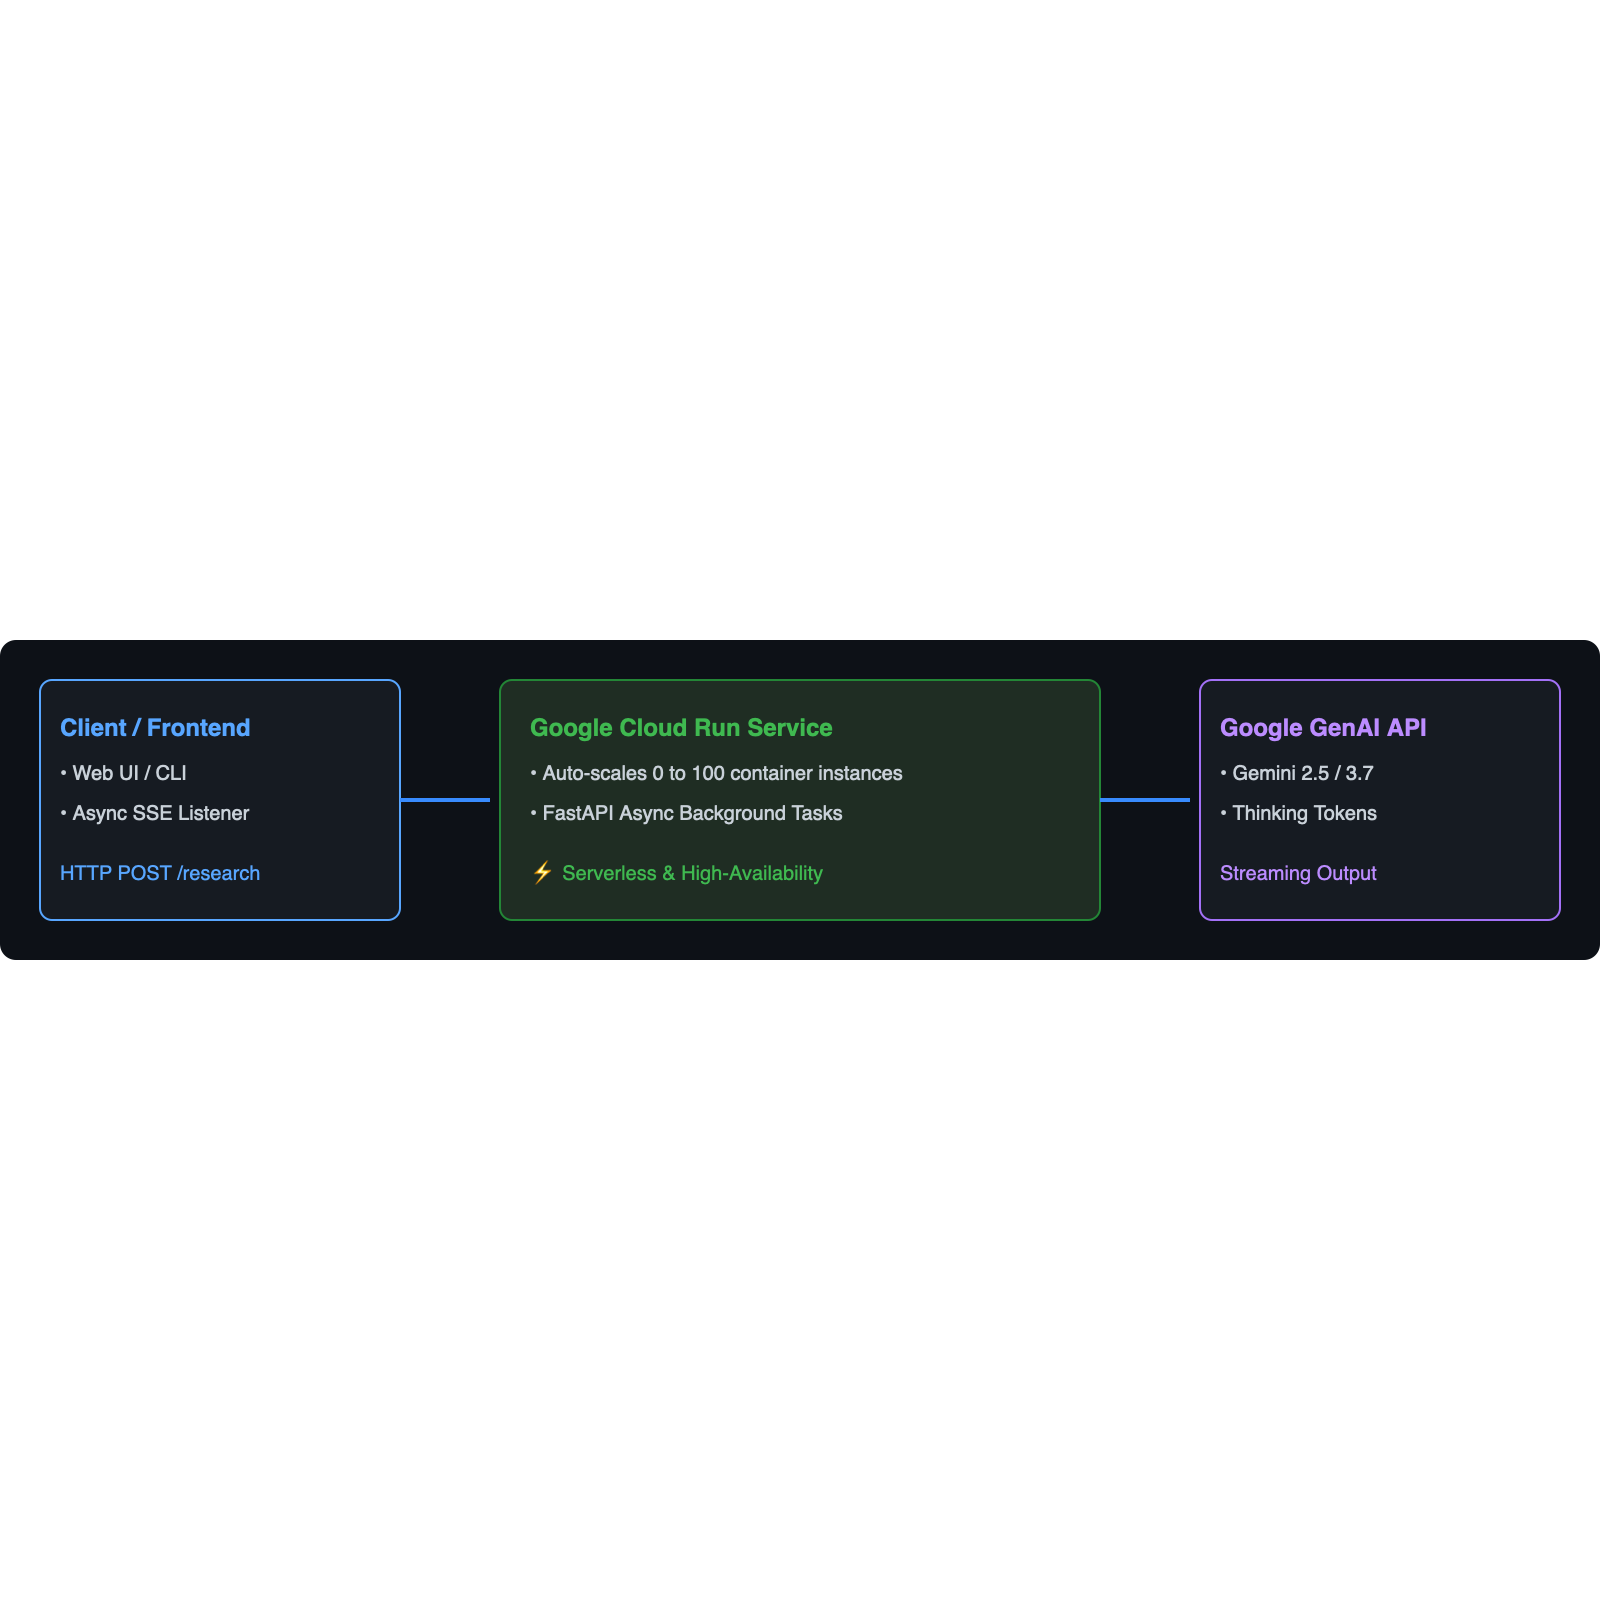
</p>

### 5.2 Microservice Container (`Dockerfile`):
```dockerfile
FROM python:3.11-slim
WORKDIR /app
COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt
COPY . .
CMD ["uvicorn", "main:app", "--host", "0.0.0.0", "--port", "8080"]
```


---
## 6. Practical Hands-On Exercises (With Beginner Hints & Starter Code)

Test your applied reasoning engineering skills by completing these three enterprise challenges:

---

### 🎯 Exercise 4.1: Best-of-N Self-Consistency Verifier
**The Business Scenario**: In critical financial calculation or database migration tasks, a single generation might contain a minor arithmetic slip. By generating 5 independent attempts and picking the verified consensus, you reach 99.9% accuracy!
- **Task**: Build `best_of_n_verifier(question: str, client: genai.Client, n_samples: int = 5)` to generate 5 candidates in parallel and pick the highest-scoring verified solution.
- **💡 Beginner Hint**: Generate candidates with `temperature=0.8` using `ThreadPoolExecutor`, then ask Gemini to grade each solution from 0 to 100.

---

### 🎯 Exercise 4.2: Tree of Thoughts (ToT) Step Evaluator
**The Business Scenario**: For complex architectural planning (like zero-downtime database migration), jumping straight to the end causes blind spots. A Tree of Thoughts explores 3 step-1 options, prunes bad ideas, and branches only the top 2 strategies!
- **Task**: Implement a 2-step Tree of Thoughts branch generator and scoring engine.
- **💡 Beginner Hint**: Use a Pydantic schema with `step_description: str`, `feasibility_score: int (1-10)`, and `risk_analysis: str`.

---

### 🎯 Exercise 4.3: Multi-Source Contradiction Triangulator
**The Business Scenario**: When an autonomous agent researches the web, Source A might claim a company raised $50M while Source B claims $75M. A Forward Deployment agent triangulates the conflicting sources and reports the discrepancy!
- **Task**: Implement `detect_factual_contradictions(findings: List[str], client: genai.Client)` to flag conflicting numbers/dates.
- **💡 Beginner Hint**: Feed the raw findings list into Gemini with instructions to identify opposing claims and return a structured verdict.


---
## 7. Step-by-Step Solutions & Architectural Explanations


In [ ]:
# ============================================================================
# SOLUTION 4.1: Best-of-N Self-Consistency Verifier
# ============================================================================
class VerificationScore(BaseModel):
    soundness_score: int = Field(description="Score from 0 to 100 on mathematical and logical soundness")
    justification: str

def best_of_n_verifier(question: str, client: genai.Client, n_samples: int = 3) -> Dict[str, Any]:
    print(f"🎲 Generating {n_samples} diverse reasoning trajectories...")
    candidates = []
    
    # Generate N candidate answers
    for i in range(n_samples):
        resp = client.models.generate_content(
            model="gemini-2.5-flash",
            contents=question,
            config=types.GenerateContentConfig(
                temperature=0.8,
                thinking_config=types.ThinkingConfig(thinking_budget=1024)
            )
        )
        candidates.append(resp.text)
        
    print("⚖️ Verifying candidates with Outcome Verifier...")
    scored_candidates = []
    for idx, cand in enumerate(candidates, 1):
        verifier_prompt = f"""
Rate the logical and mathematical correctness of this solution on a scale of 0 to 100:

[PROBLEM]:
{question}

[SOLUTION CANDIDATE]:
{cand}
"""
        score_resp = client.models.generate_content(
            model="gemini-2.5-flash",
            contents=verifier_prompt,
            config=types.GenerateContentConfig(
                response_mime_type="application/json",
                response_schema=VerificationScore,
                temperature=0.0
            )
        )
        score_data = VerificationScore.model_validate_json(score_resp.text)
        scored_candidates.append({
            "candidate_id": idx,
            "text": cand,
            "score": score_data.soundness_score,
            "justification": score_data.justification
        })
        
    best_candidate = max(scored_candidates, key=lambda x: x["score"])
    return {
        "best_candidate": best_candidate,
        "all_scores": [c["score"] for c in scored_candidates]
    }

# Test Best-of-N
math_problem = "Prove whether the sum of any two rational numbers is always rational, and provide an algebraic proof."
bon_result = best_of_n_verifier(math_problem, client, n_samples=3)

print("
🏆 Top-Scoring Trajectory:")
print(f"Score: {bon_result['best_candidate']['score']}/100")
print(f"Justification: {bon_result['best_candidate']['justification']}")
print(f"Solution Snippet:
{bon_result['best_candidate']['text'][:250]}...")


In [ ]:
# ============================================================================
# SOLUTION 4.2: Tree of Thoughts (ToT) Branching & Pruning
# ============================================================================
class ThoughtBranch(BaseModel):
    branch_id: str
    action_description: str
    feasibility_score: int = Field(description="Feasibility score from 1 to 10")
    risk_assessment: str

class ToTStepResult(BaseModel):
    candidate_branches: List[ThoughtBranch]

def expand_and_evaluate_thoughts(goal: str, client: genai.Client) -> ToTStepResult:
    prompt = f"""
You are a Tree-of-Thoughts (ToT) Planner.
Goal: "{goal}"

Generate 3 distinct, divergent strategic initial steps (Branches A, B, C).
Score each branch for feasibility (1-10) and evaluate its risks.
"""
    resp = client.models.generate_content(
        model="gemini-2.5-flash",
        contents=prompt,
        config=types.GenerateContentConfig(
            response_mime_type="application/json",
            response_schema=ToTStepResult,
            temperature=0.7
        )
    )
    return ToTStepResult.model_validate_json(resp.text)

tot_results = expand_and_evaluate_thoughts("Migrate a 50TB monolithic MySQL database to Google Cloud Spanner with zero downtime.", client)
print("🌳 Tree of Thoughts Exploration Branches:")
for b in sorted(tot_results.candidate_branches, key=lambda x: x.feasibility_score, reverse=True):
    print(f"• [{b.branch_id}] Score: {b.feasibility_score}/10 -> {b.action_description}")
    print(f"  ⚠️ Risk: {b.risk_assessment}")


In [ ]:
# ============================================================================
# SOLUTION 4.3: Contradiction Detection & Reconciliation
# ============================================================================
class ContradictionReport(BaseModel):
    contradictions_found: bool
    discrepancies: List[str] = Field(description="List of specific numerical or factual contradictions")
    reconciled_consensus: str = Field(description="The most credible reconciled factual summary")

def detect_factual_contradictions(findings: List[str], client: genai.Client) -> ContradictionReport:
    prompt = f"""
Analyze these extracted research findings from multiple independent web sources:

{chr(10).join(f"- Source {i+1}: {f}" for i, f in enumerate(findings))}

Identify any contradictory data points, statistics, or dates, and synthesize a reconciled consensus.
"""
    resp = client.models.generate_content(
        model="gemini-2.5-flash",
        contents=prompt,
        config=types.GenerateContentConfig(
            response_mime_type="application/json",
            response_schema=ContradictionReport,
            temperature=0.0
        )
    )
    return ContradictionReport.model_validate_json(resp.text)

# Test contradictory inputs
test_findings = [
    "Source A reports that Company X achieved $14.2B in cloud revenue in Q4 2025, growing 28% YoY.",
    "Source B claims Company X reported $12.8B in cloud revenue for Q4 2025, with growth slowing to 19% YoY.",
    "Source C states that Company X total cloud ARR surpassed $50B by end of 2025."
]

contra_report = detect_factual_contradictions(test_findings, client)
print("🔎 Contradiction Analysis Report:")
print(f"• Contradictions Found: {contra_report.contradictions_found}")
print(f"• Discrepancies: {contra_report.discrepancies}")
print(f"• Reconciled Consensus: {contra_report.reconciled_consensus}")


---
## Summary & Key Takeaways
1. **Thinking Tokens & Reasoning Models**: Allocating test-time compute unlocks step-by-step backtracking, mathematical verification, and exploration.
2. **Inference-Time Scaling**: Techniques like Best-of-$N$, Tree of Thoughts, and Verifier Scoring scale model performance at test-time without requiring model retraining.
3. **Deep Research Engine**: Automating recursive topic planning, multi-source ingestion, contradiction reconciliation, and whitepaper synthesis transforms hours of manual analyst work into seconds of autonomous execution.
4. **Next Step**: In **Project 5**, we explore **Multimodal Generation, Vision & Video Understanding, Diffusion Architectures, and Imagen 3 Asset Generation**!
